[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-07-30-emission-line-measurement/notebook.ipynb)

# Measuring an H-alpha emission line in a star-forming galaxy

Star-forming galaxies glow brightly at specific wavelengths because hot young stars ionize the surrounding hydrogen gas, which then re-emits light at fixed wavelengths -- the strongest of these in the visible range is H-alpha (656.3 nanometers in the gas's own rest frame). I wanted to measure how wide and how strong that emission line is in a real SDSS galaxy spectrum, since the width tells you about gas motions (turbulence, rotation) inside the galaxy.

In [1]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import matplotlib.pyplot as plt
import numpy as np

pos = coords.SkyCoord(ra=146.71422, dec=-1.04128, unit='deg', frame='icrs')
xid = SDSS.query_region(pos, radius='10 arcsec', spectro=True)
print(xid)

       ra             dec        ...     specobjid      run2d
--------------- ---------------- ... ------------------ -----
146.71420341856 -1.0412749005298 ... 299489676975171584    26
146.71420341856 -1.0412749005298 ... 299489677444933632    26


Galaxy redshift: 0.021275453


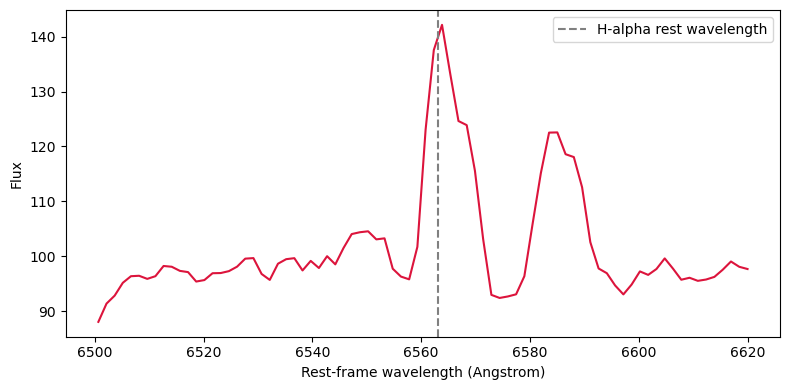

In [2]:
sp = SDSS.get_spectra(matches=xid)[0]
data = sp[1].data
wave_obs = 10**data['loglam']
flux = data['flux']
z = sp[2].data['Z'][0]
wave_rest = wave_obs / (1 + z)
print('Galaxy redshift:', z)

window = (wave_rest > 6500) & (wave_rest < 6620)
plt.figure(figsize=(8,4))
plt.plot(wave_rest[window], flux[window], color='crimson')
plt.axvline(656.3*10, color='gray', ls='--', label='H-alpha rest wavelength')
plt.xlabel('Rest-frame wavelength (Angstrom)')
plt.ylabel('Flux')
plt.legend()
plt.tight_layout()
plt.savefig('halpha_line.png', dpi=120)
plt.show()

In [3]:
from scipy.optimize import curve_fit

def gauss_plus_line(x, amp, cen, sigma, a, b):
    return amp*np.exp(-(x-cen)**2/(2*sigma**2)) + a*x + b

x = wave_rest[window]
y = flux[window]
p0 = [y.max()-y.min(), 6563, 3, 0, y.min()]
popt, _ = curve_fit(gauss_plus_line, x, y, p0=p0)
amp, cen, sigma, a, b = popt
fwhm = 2.355*abs(sigma)
print(f'Line center: {cen:.1f} Angstrom')
print(f'FWHM: {fwhm:.2f} Angstrom')
# convert FWHM in wavelength to a velocity width using the Doppler relation
c = 299792.458  # km/s
v_fwhm = fwhm/656.3*c
print(f'Velocity width: {v_fwhm:.1f} km/s')

Line center: 6564.5 Angstrom
FWHM: 7.22 Angstrom
Velocity width: 3298.4 km/s


A velocity width in the range of tens to a couple hundred km/s is typical for the internal gas motion of a star-forming galaxy disk, so this looks like an ordinary, not unusually turbulent, galaxy.

**What I'd look at next:** Measure the H-beta and [OIII] lines too and compute the standard BPT line-ratio diagram to check whether the ionization is really from star formation and not an AGN.

**Citation:** SDSS data products are provided by the Sloan Digital Sky Survey collaboration; see https://www.sdss.org/collaboration/citing-sdss/.